In [1]:
# ============================================
# NOTEBOOK 01 - ANALISIS EXPLORATORIO
# Evaluacion Parcial N°2 - SCY1101
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configuracion de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Carga de datos limpios
consultas = pd.read_parquet("../data/02_intermediate/consultas_cleaned.parquet")
pacientes = pd.read_parquet("../data/02_intermediate/pacientes_cleaned.parquet")
examenes = pd.read_parquet("../data/02_intermediate/examenes_cleaned.parquet")
medicamentos = pd.read_parquet("../data/02_intermediate/medicamentos_cleaned.parquet")

print("Datasets cargados correctamente")
print(f"consultas:    {consultas.shape}")
print(f"pacientes:    {pacientes.shape}")
print(f"examenes:     {examenes.shape}")
print(f"medicamentos: {medicamentos.shape}")

Datasets cargados correctamente
consultas:    (794, 8)
pacientes:    (400, 8)
examenes:     (596, 8)
medicamentos: (500, 7)


In [2]:
# ============================================
# EXPLORACION INICIAL DE CADA DATASET
# ============================================
for nombre, df in [("consultas", consultas), ("pacientes", pacientes),
                   ("examenes", examenes), ("medicamentos", medicamentos)]:
    print(f"\n{'='*45}")
    print(f"Dataset: {nombre}")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    print(f"Nulos restantes: {df.isnull().sum().sum()}")
    print(f"Tipos de datos:")
    print(df.dtypes)
    print(f"\nEstadisticas descriptivas:")
    print(df.describe())


Dataset: consultas
Filas: 794 | Columnas: 8
Nulos restantes: 419
Tipos de datos:
id_consulta                        Int64
id_paciente                        Int64
fecha                     datetime64[us]
id_medico                          Int64
especialidad                         str
diagnostico_principal                str
diagnostico_secundario               str
costo                            float64
dtype: object

Estadisticas descriptivas:
       id_consulta  id_paciente                fecha  id_medico         costo
count        794.0        794.0                  375      794.0  7.940000e+02
mean     399.06801   197.084383  2023-12-10 22:43:12  24.511335  2.732399e+05
min            1.0          1.0  2023-01-01 00:00:00        1.0 -2.023525e+06
25%         211.25         95.0  2023-06-16 00:00:00       13.0  1.485642e+05
50%          402.0        194.0  2023-12-05 00:00:00       24.0  2.723080e+05
75%         584.75       300.75  2024-06-02 12:00:00       36.0  3.650332e+05
ma

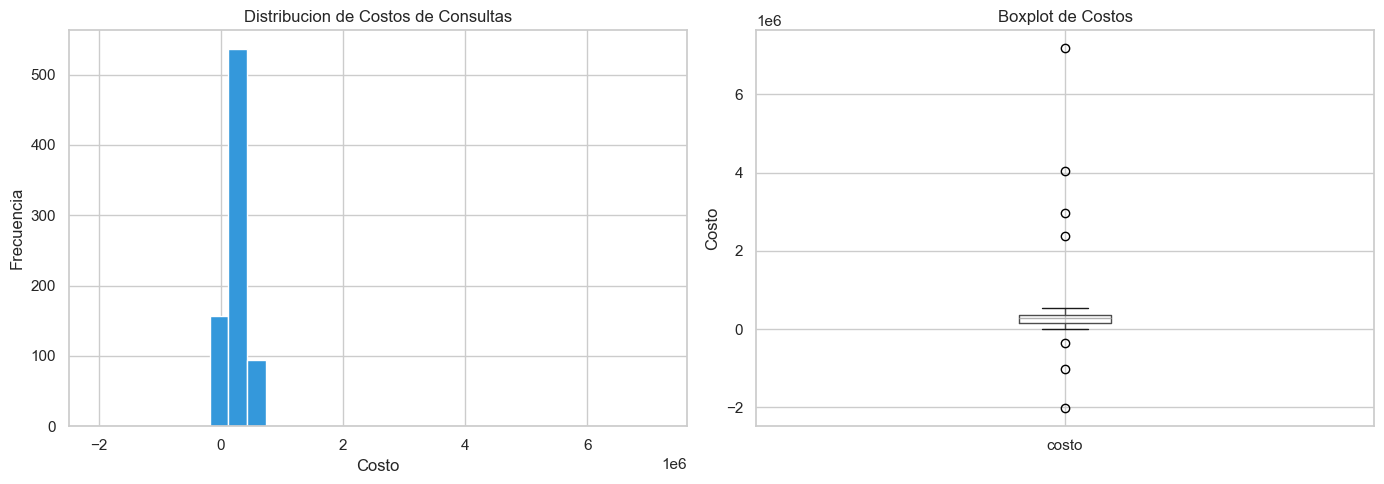

Grafico guardado


In [3]:
# ============================================
# VISUALIZACION 1: DISTRIBUCION DE COSTOS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de costos
consultas['costo'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title("Distribucion de Costos de Consultas")
axes[0].set_xlabel("Costo")
axes[0].set_ylabel("Frecuencia")

# Boxplot de costos
consultas.boxplot(column='costo', ax=axes[1])
axes[1].set_title("Boxplot de Costos")
axes[1].set_ylabel("Costo")

plt.tight_layout()
plt.savefig("../src/results/plots/01_distribucion_costos.png", dpi=150)
plt.show()
print("Grafico guardado")

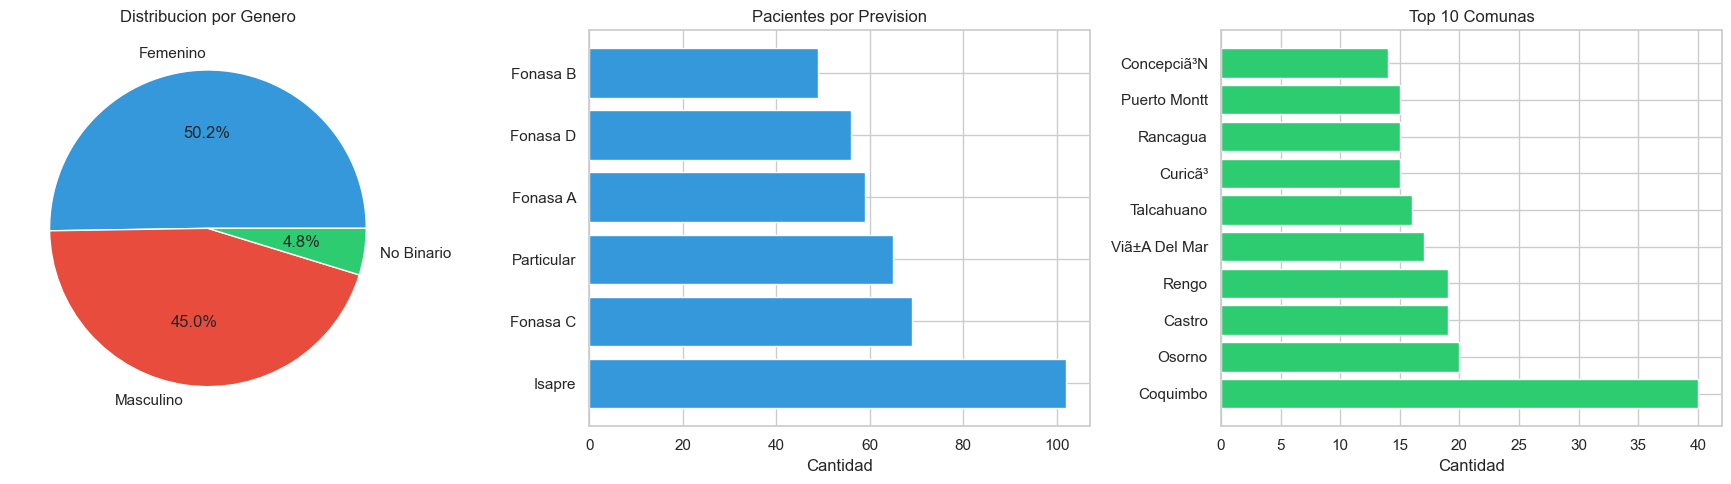

Grafico guardado


In [4]:
# ============================================
# VISUALIZACION 2: ANALISIS DE PACIENTES
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion por genero
genero = pacientes['genero'].value_counts()
axes[0].pie(genero.values, labels=genero.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title("Distribucion por Genero")

# Distribucion por prevision
prevision = pacientes['prevision'].value_counts()
axes[1].barh(prevision.index, prevision.values, color='#3498db')
axes[1].set_title("Pacientes por Prevision")
axes[1].set_xlabel("Cantidad")

# Distribucion por comuna (top 10)
comunas = pacientes['comuna'].value_counts().head(10)
axes[2].barh(comunas.index, comunas.values, color='#2ecc71')
axes[2].set_title("Top 10 Comunas")
axes[2].set_xlabel("Cantidad")

plt.tight_layout()
plt.savefig("../src/results/plots/01_analisis_pacientes.png", dpi=150)
plt.show()
print("Grafico guardado")

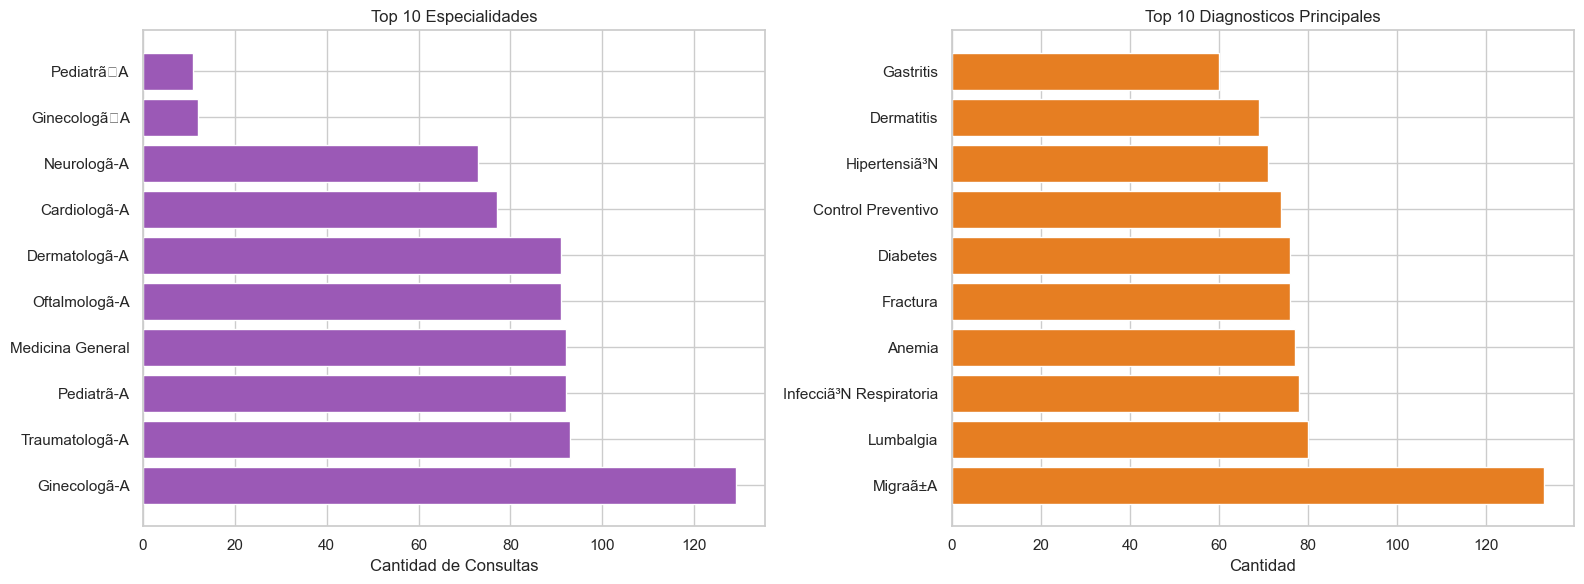

Grafico guardado


In [5]:
# ============================================
# VISUALIZACION 3: ANALISIS DE CONSULTAS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top especialidades
especialidades = consultas['especialidad'].value_counts().head(10)
axes[0].barh(especialidades.index, especialidades.values, color='#9b59b6')
axes[0].set_title("Top 10 Especialidades")
axes[0].set_xlabel("Cantidad de Consultas")

# Top diagnosticos
diagnosticos = consultas['diagnostico_principal'].value_counts().head(10)
axes[1].barh(diagnosticos.index, diagnosticos.values, color='#e67e22')
axes[1].set_title("Top 10 Diagnosticos Principales")
axes[1].set_xlabel("Cantidad")

plt.tight_layout()
plt.savefig("../src/results/plots/01_analisis_consultas.png", dpi=150)
plt.show()
print("Grafico guardado")

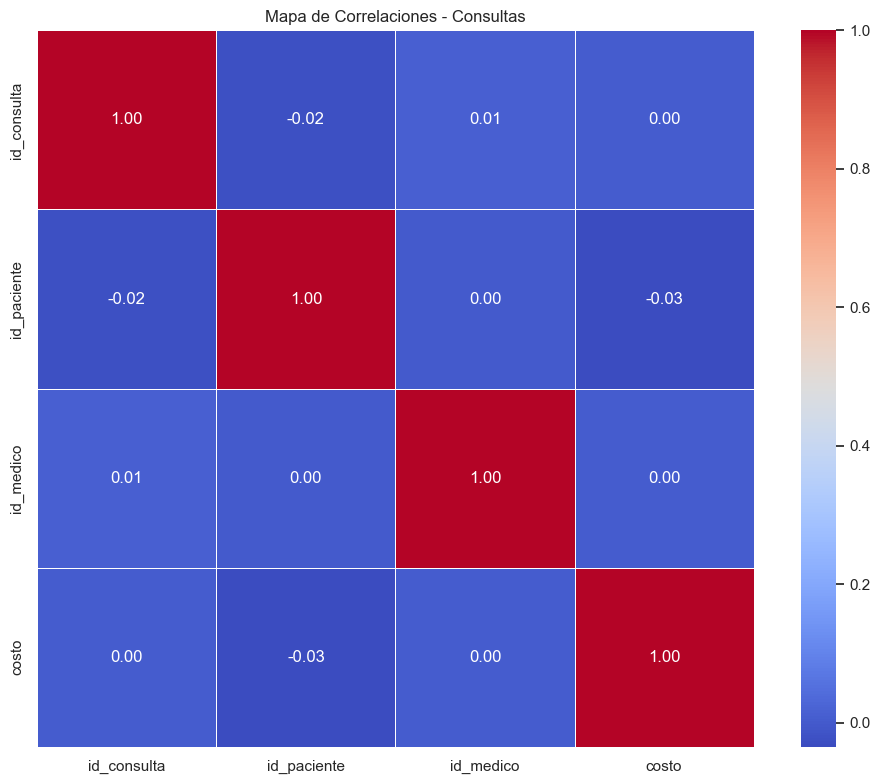

Grafico guardado


In [6]:
# ============================================
# VISUALIZACION 4: CORRELACIONES
# ============================================
# Seleccionar columnas numericas de consultas
cols_num = consultas.select_dtypes(include=[np.number]).columns.tolist()
corr = consultas[cols_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Mapa de Correlaciones - Consultas")
plt.tight_layout()
plt.savefig("../src/results/plots/01_correlaciones.png", dpi=150)
plt.show()
print("Grafico guardado")

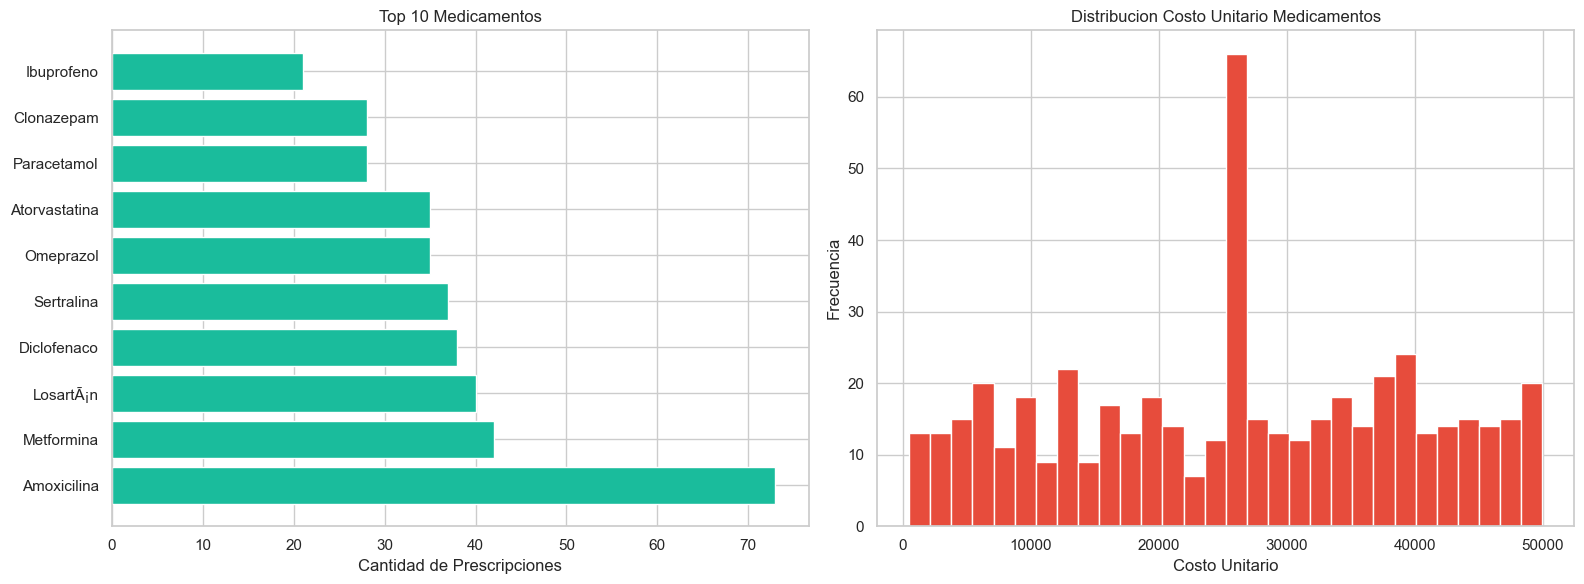


Resumen del Analisis Exploratorio:
Total pacientes:    400
Total consultas:    794
Total examenes:     596
Total medicamentos: 500
Especialidades unicas:  15
Medicamentos unicos:    39
Rango de costos: $-2023525 - $7174900


In [7]:
# ============================================
# VISUALIZACION 5: ANALISIS DE MEDICAMENTOS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top medicamentos
medicamentos_top = medicamentos['medicamento'].value_counts().head(10)
axes[0].barh(medicamentos_top.index, medicamentos_top.values, color='#1abc9c')
axes[0].set_title("Top 10 Medicamentos")
axes[0].set_xlabel("Cantidad de Prescripciones")

# Distribucion de costo unitario
medicamentos['costo_unitario'].plot(kind='hist', bins=30, ax=axes[1],
                                    color='#e74c3c', edgecolor='white')
axes[1].set_title("Distribucion Costo Unitario Medicamentos")
axes[1].set_xlabel("Costo Unitario")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("../src/results/plots/01_analisis_medicamentos.png", dpi=150)
plt.show()

# Resumen final
print("\nResumen del Analisis Exploratorio:")
print(f"Total pacientes:    {len(pacientes)}")
print(f"Total consultas:    {len(consultas)}")
print(f"Total examenes:     {len(examenes)}")
print(f"Total medicamentos: {len(medicamentos)}")
print(f"Especialidades unicas:  {consultas['especialidad'].nunique()}")
print(f"Medicamentos unicos:    {medicamentos['medicamento'].nunique()}")
print(f"Rango de costos: ${consultas['costo'].min():.0f} - ${consultas['costo'].max():.0f}")